In [1]:
import csv
import pysam
import duckdb
import regex as re
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
bams = {
    "hp_f1": "../data/BEGONIA_2/begonia_2_sup_v5_no_trim_no_filter.bam",
    "nj_f1": "../data/BEGONIA_4/begonia_4_sup_v5_no_trim_no_filter.bam",
    "hp_p2": "../data/CAMELLIA_007/camellia_007_sup_v5_no_trim_no_filter.bam",
    "nj_p2": "../data/CAMELLIA_008/camellia_008_sup_v5_no_trim_no_filter.bam",
    "hp_c1": "../data/CAMELLIA_11/camellia_11_sup_v5_no_trim_no_filter.bam",
    "nj_c1": "../data/CAMELLIA_17/camellia_17_sup_v5_no_trim_no_filter.bam",
}

In [3]:
# parse bams
def tab_qc_bam(bam_dict, out, only_primary=False, check_sq=False):
    data = []
    for sample_name, bam_path in bam_dict.items():
        with pysam.AlignmentFile(bam_path, "rb", check_sq=check_sq) as bamfile:
            for read in bamfile:
                if only_primary and (read.is_unmapped or read.is_secondary or read.is_supplementary):
                    continue
                read_length = read.query_length
                if read_length is None:
                    qs = read.query_sequence
                    read_length = len(qs) if qs is not None else None
                data.append({
                    "sample": sample_name,
                    "read_name": read.query_name,
                    "read_length": read_length,
                    "qs": read.get_tag("qs") if read.has_tag("qs") else None,
                    "st": read.get_tag("st") if read.has_tag("st") else None,
                })
    df = pd.DataFrame(data, columns=["sample", "read_name", "read_length", "qs", "st"])
    if out and not df.empty:
        df.to_parquet(out, index=False)


In [4]:
# get primary alignments
tab_qc_bam(
    {k: v for k, v in bams.items() if re.search(r"f1$", k)},
    out = "../results/qc_stats_f1.parquet"
)
tab_qc_bam(
    {k: v for k, v in bams.items() if re.search(r"p2$", k)},
    out = "../results/qc_stats_p2.parquet"
)
tab_qc_bam(
    {k: v for k, v in bams.items() if re.search(r"c1$", k)},
    out = "../results/qc_stats_c1.parquet"
)

In [5]:
# connect
con = duckdb.connect()

# query Parquet files with a glob
query = """
SELECT *
FROM read_parquet('../results/qc_stats_*.parquet')
WHERE qs IS NOT NULL AND st IS NOT NULL
"""

df = con.execute(query).fetchdf()

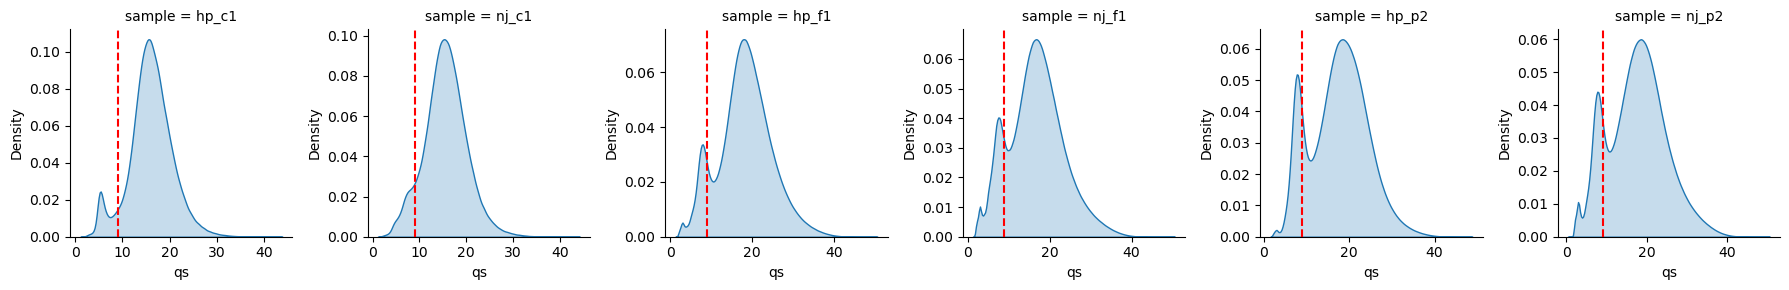

In [6]:
p1 = sns.FacetGrid(df, col="sample", sharex=False, sharey=False)
p1.map(sns.kdeplot, "qs", fill=True)
for ax in p1.axes.flatten():
    ax.axvline(9, color='red', linestyle='--')

plt.show()

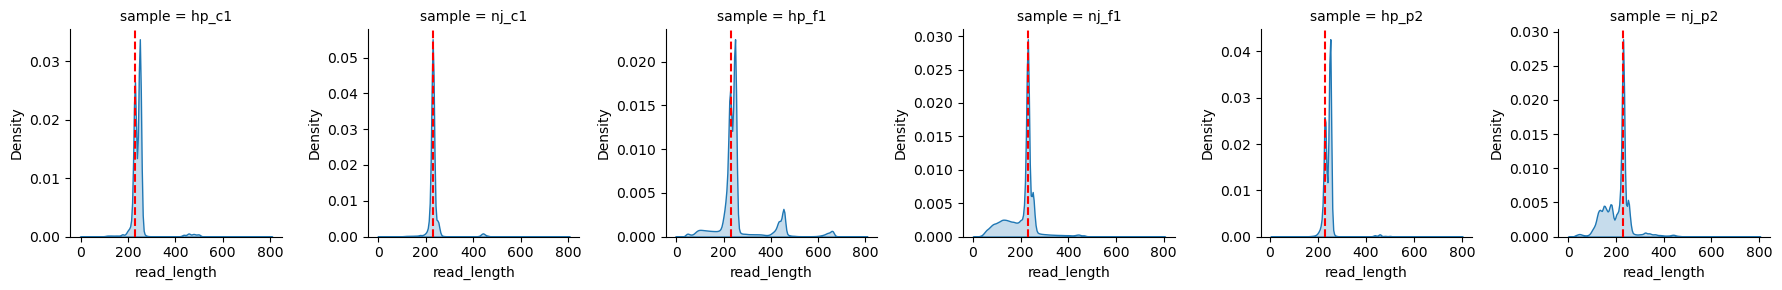

In [7]:
df_len = df[(df["read_length"] <= 800)]

p2 = sns.FacetGrid(df_len, col="sample", sharex=False, sharey=False)
p2.map(sns.kdeplot, "read_length", fill=True)

for ax in p2.axes.flatten():
    ax.axvline(230, color='red', linestyle='--')
    
plt.show()

In [8]:
counts = (
    df.assign(
        st_dt=pd.to_datetime(df['st']),
        st_minute=lambda d: d['st_dt'].dt.floor('min')
    )
    .groupby(['sample', 'st_minute'])
    .size()
    .reset_index(name='count')
    .sort_values(['sample', 'st_minute'])
    .assign(
        cumulative_count=lambda d: d.groupby('sample')['count'].cumsum(),
        minute_offset=lambda d: d.groupby('sample')['st_minute'].transform(
            lambda s: (s - s.min()).dt.total_seconds() / 60.0
        ),
        pool=lambda d: d['sample'].str.split('_').str[1]
    )
)


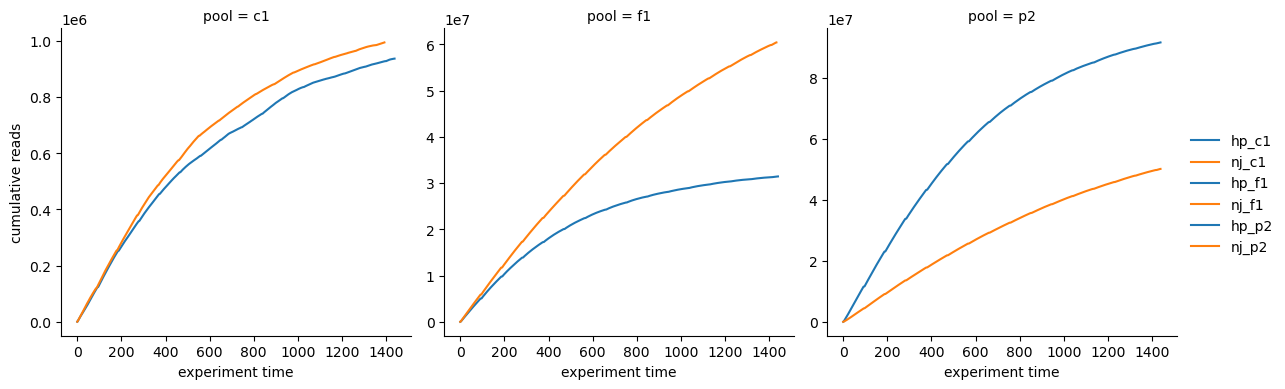

In [9]:
p3=sns.FacetGrid(
    counts,
    col="pool",
    col_wrap=3,
    sharex=True,
    sharey=False,
    height=4
)

p3.map_dataframe(
    sns.lineplot,
    x="minute_offset",
    y="cumulative_count",
    hue="sample"
)

p3.set_axis_labels("experiment time", "cumulative reads")
p3.add_legend()

plt.show()

In [10]:
qced_counts = (
    df
    .query("qs >= 9")
    .groupby("sample")
    .size()
    .reset_index(name="read_count")
    .assign(
        pool=lambda d: d['sample'].str.split('_').str[1],
        prot=lambda d: d['sample'].str.split('_').str[0]
    )
)

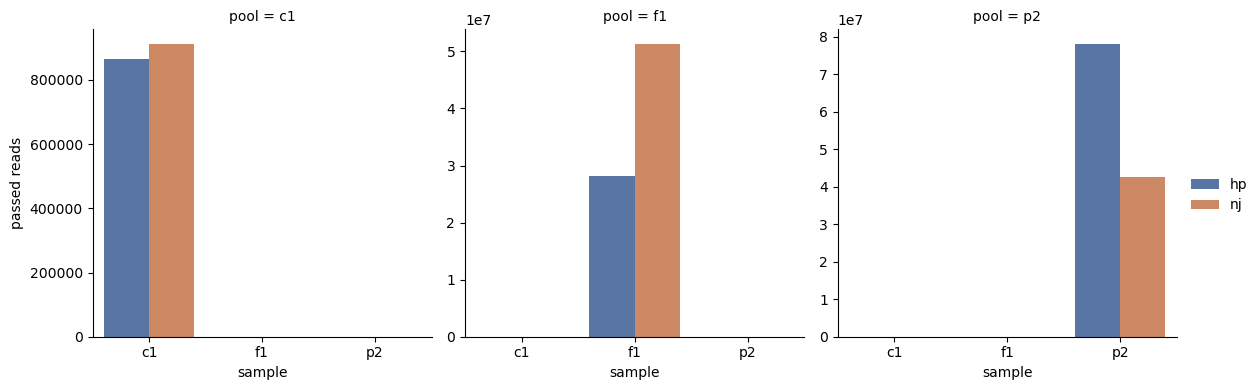

In [11]:
p4=sns.FacetGrid(
    qced_counts,
    col="pool",
    col_wrap=3,
    sharex=True,
    sharey=False,
    height=4
)

p4.map_dataframe(
    sns.barplot,
    x="pool",
    y="read_count",
    hue="prot",
    palette="deep"
)

p4.set_axis_labels("sample", "passed reads")
p4.add_legend()

plt.show()